# AtlanticRe — Axe 3 Bloc 4 : TOPSIS Multi-Critères
## Scoring des Marchés d'Assurance Africains 2030

> **Méthode** : TOPSIS (Technique for Order of Preference by Similarity to Ideal Solution)  
> **Inputs** : `predictions_2025_2030_AtlanticRe.csv` + `pca_loadings_2030_AtlanticRe.csv`  
> **Output** : `scoring_topsis_2030_AtlanticRe.csv`

---

**Principe** : TOPSIS classe les pays selon leur proximité relative à la solution idéale (meilleure valeur possible sur chaque critère) et leur éloignement de la solution anti-idéale (pire valeur). Contrairement à une somme pondérée, TOPSIS gère les compensations asymétriques et est sensible aux compromis.

**Variantes implémentées** :
1. **TOPSIS classique** — poids issus de la PCA (Bloc 1)
2. **Analyse de sensibilité** — variation ±20% de chaque poids
3. **Fuzzy TOPSIS** — triplets (lb80, pred, ub80) pour intégrer l'incertitude prédictive

---
## 0. Setup & Chargement

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors
import seaborn as sns
from itertools import product
import warnings
warnings.filterwarnings('ignore')

# ── Paramètres globaux ─────────────────────────────────────────────────────
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

REGIONS = {
    'Afrique du Nord'    : ['Algérie', 'Égypte', 'Maroc', 'Tunisie'],
    "Afrique de l'Ouest" : ['Bénin', 'Burkina Faso', 'Cap-Vert', "Côte d'Ivoire",
                            'Ghana', 'Mali', 'Mauritanie', 'Niger', 'Nigeria',
                            'Sénégal', 'Togo'],
    'Afrique Centrale'   : ['Cameroun', 'Congo', 'Gabon', 'RDC', 'Tchad'],
    "Afrique de l'Est"   : ['Burundi', 'Éthiopie', 'Kenya', 'Madagascar',
                            'Mozambique', 'Ouganda', 'Tanzanie'],
    'Afrique Australe'   : ['Angola', 'Botswana', 'Malawi', 'Maurice',
                            'Namibie', 'Zambie']
}

REGION_COLORS = {
    'Afrique du Nord'    : '#e63946',
    "Afrique de l'Ouest" : '#2a9d8f',
    'Afrique Centrale'   : '#e9c46a',
    "Afrique de l'Est"   : '#457b9d',
    'Afrique Australe'   : '#8338ec',
}

# Critères TOPSIS
CRITERIA_COLS = [
    'nv_penetration_pred',
    'vie_penetration_pred',
    'nv_sp_pred',
    'gdpcap_pred',
    'polstab_pred',
    'regqual_pred',
    'nv_primes_pred',
    'nv_densite_pred',
]

# Critères bénéfiques (+) vs coût (−)
BENEFICIAL = {'nv_penetration_pred', 'vie_penetration_pred', 'gdpcap_pred',
              'polstab_pred', 'regqual_pred', 'nv_primes_pred', 'nv_densite_pred'}
COST       = {'nv_sp_pred'}   # minimiser S/P = chercher la rentabilité

# Colonnes d'intervalle pour le Fuzzy TOPSIS
IC_COLS = {
    'nv_penetration_pred' : ('nv_penetration_lb80', 'nv_penetration_ub80'),
    'vie_penetration_pred': ('vie_penetration_lb80', 'vie_penetration_ub80'),
    'nv_sp_pred'          : ('nv_sp_lb80',           'nv_sp_ub80'),
    'gdpcap_pred'         : ('gdpcap_lb80',           'gdpcap_ub80'),
    'polstab_pred'        : ('polstab_lb80',          'polstab_ub80'),
    'regqual_pred'        : ('regqual_lb80',          'regqual_ub80'),
    'nv_primes_pred'      : None,  # pas d'IC disponible
    'nv_densite_pred'     : None,  # pas d'IC disponible
}

print('✅ Setup OK')
print(f'   Critères bénéfiques : {len(BENEFICIAL)}')
print(f'   Critères coût       : {len(COST)}')

✅ Setup OK
   Critères bénéfiques : 7
   Critères coût       : 1


In [3]:
# ── Chargement des données ─────────────────────────────────────────────────
df_pred_all = pd.read_csv('predictions_2025_2030_AtlanticRe.csv')
assert not df_pred_all.empty, "Le fichier CSV chargé est vide — vérifier le chemin"
df_loadings = pd.read_csv('pca_loadings_2030_AtlanticRe.csv', index_col=0)
assert not df_loadings.empty, "Le fichier CSV chargé est vide — vérifier le chemin"

# ── Vérifications d'intégrité du CSV Bloc 1 ──────────────────────────────
assert 'Variable' in df_loadings.columns, \
    "Colonne 'Variable' manquante — vérifier l'export Bloc 1"
assert 'poids_pca_implicit' in df_loadings.columns, \
    "Colonne 'poids_pca_implicit' manquante — vérifier le Bloc 1 (typo possible)"
# Bloc 1 exporte 'nv_sp_inv' (variable inversée pour la PCA).
# Bloc 4 travaille sur 'nv_sp_pred' (valeur brute, l'inversion est gérée via COST).
# On remplace le nom dans le CSV de loadings pour aligner les deux blocs.
df_loadings['Variable'] = df_loadings['Variable'].replace({'nv_sp_inv': 'nv_sp_pred'})

assert set(df_loadings['Variable']) == set(CRITERIA_COLS), \
    f"Variables PCA \u2260 CRITERIA_COLS TOPSIS \u2014 delta: "\
    f"{set(df_loadings['Variable']) ^ set(CRITERIA_COLS)}"

# Optionnel : score Axe 2 pour comparaison
try:
    # index_col=0 : le CSV est exporté avec index=True (rangs 1..33) depuis Axe 2.
    # Sans index_col=0, l'index numérique du CSV devient une colonne anonyme et
    # df_axe2.index repart de 0 → rang_axe2 = index+1 serait off-by-one.
    df_axe2 = pd.read_csv('score_attractivite_2030_AtlanticRe.csv', index_col=0)
    assert not df_axe2.empty, "Le fichier CSV chargé est vide — vérifier le chemin"
    HAS_AXE2 = True
    print('✅ score_attractivite_2030_AtlanticRe.csv chargé')
except FileNotFoundError:
    HAS_AXE2 = False
    print('⚠️  score_attractivite_2030_AtlanticRe.csv non trouvé — comparaison Axe 2 désactivée')

# Optionnel : scoring Monte Carlo
try:
    df_mc = pd.read_csv('scoring_mc_2030_AtlanticRe.csv')
    assert not df_mc.empty, "Le fichier CSV chargé est vide — vérifier le chemin"
    HAS_MC = True
    print('✅ scoring_mc_2030_AtlanticRe.csv chargé')
except FileNotFoundError:
    HAS_MC = False
    print('⚠️  scoring_mc_2030_AtlanticRe.csv non trouvé — comparaison MC désactivée')

# Filtrer sur 2030
df_2030 = df_pred_all[df_pred_all['Year'] == 2030].copy().reset_index(drop=True)

# Vérification
assert df_2030['Pays'].nunique() == 33, f"ERREUR : {df_2030['Pays'].nunique()} pays trouvés (attendu 33)"
print(f'\n📊 df_2030 : {df_2030.shape[0]} lignes × {df_2030.shape[1]} colonnes')
print(f'   {df_2030["Pays"].nunique()} pays ✅')
print(f'\n📊 pca_loadings : {df_loadings.shape}')
print(df_loadings[['Variable', 'poids_pca_implicit']])

✅ score_attractivite_2030_AtlanticRe.csv chargé
✅ scoring_mc_2030_AtlanticRe.csv chargé

📊 df_2030 : 33 lignes × 38 colonnes
   33 pays ✅

📊 pca_loadings : (8, 5)
                                  Variable  poids_pca_implicit
NV Pénétration (%)     nv_penetration_pred              0.1341
Vie Pénétration (%)   vie_penetration_pred              0.0637
Ratio S/P (%)                   nv_sp_pred              0.1367
PIB/hab (USD)                  gdpcap_pred              0.1588
Stabilité Politique           polstab_pred              0.1003
Qualité Régl.                 regqual_pred              0.1424
NV Primes (M USD)           nv_primes_pred              0.1028
NV Densité (USD/hab)       nv_densite_pred              0.1611


---
## 1. Préparation de la Matrice de Décision

In [4]:
# ── Matrice de décision brute ──────────────────────────────────────────────
D = df_2030[CRITERIA_COLS].values.astype(float)   # shape (33, 8)
pays_list   = df_2030['Pays'].tolist()
region_list = df_2030['Region'].tolist()

N_PAYS, N_CRIT = D.shape
print(f'Matrice de décision D : {N_PAYS} pays × {N_CRIT} critères')

# Stats descriptives
df_desc = pd.DataFrame(D, index=pays_list, columns=CRITERIA_COLS)
print('\nStatistiques des critères 2030 :')
print(df_desc.describe().round(3).T[
    ['mean', 'std', 'min', '25%', '50%', '75%', 'max']
])

Matrice de décision D : 33 pays × 8 critères

Statistiques des critères 2030 :
                          mean       std      min       25%       50%  \
nv_penetration_pred      0.701     0.513    0.116     0.357     0.533   
vie_penetration_pred     1.198     1.875    0.090     0.316     0.588   
nv_sp_pred              37.663    11.475   17.590    30.670    33.850   
gdpcap_pred           3032.730  2946.033  349.800  1092.800  2110.900   
polstab_pred            -0.595     0.868   -2.295    -1.290    -0.451   
regqual_pred            -0.483     0.487   -1.336    -0.794    -0.531   
nv_primes_pred         569.480   784.865   30.400   109.140   351.520   
nv_densite_pred         30.157    54.011    1.110     3.780    10.190   

                           75%        max  
nv_penetration_pred      0.772      1.991  
vie_penetration_pred     1.217     10.000  
nv_sp_pred              45.870     61.840  
gdpcap_pred           3473.300  15155.500  
polstab_pred            -0.145      1.136  

---
## 2. Paramétrage des Poids (depuis la PCA)

In [5]:
# ── Extraction des poids PCA ───────────────────────────────────────────────
# Les poids PCA implicites (variance expliquée × |loading|) sont normalisés à 1

poids_pca_raw = df_loadings.set_index('Variable')['poids_pca_implicit'].to_dict()

# Construire le vecteur de poids dans l'ordre de CRITERIA_COLS
w_pca_raw = np.array([poids_pca_raw[c] for c in CRITERIA_COLS])

# Normaliser pour sommer à 1
W_PCA = w_pca_raw / w_pca_raw.sum()

# Poids manuels Axe 2 (référence)
SCORE_WEIGHTS_AXE2 = {
    'nv_penetration_pred' : 0.30,
    'nv_sp_pred'          : 0.25,
    'gdpcap_pred'         : 0.20,
    'polstab_pred'        : 0.12,
    'regqual_pred'        : 0.08,
    'vie_penetration_pred': 0.05,
    'nv_primes_pred'      : 0.00,
    'nv_densite_pred'     : 0.00,
}
w_axe2_raw = np.array([SCORE_WEIGHTS_AXE2.get(c, 0) for c in CRITERIA_COLS])
W_AXE2 = w_axe2_raw  # déjà à 1

# Poids équipondérés (benchmark)
W_EQUAL = np.ones(N_CRIT) / N_CRIT

print('Comparaison des jeux de poids :\n')
df_poids = pd.DataFrame({
    'Critère'    : CRITERIA_COLS,
    'PCA'        : np.round(W_PCA, 4),
    'Axe 2'      : np.round(W_AXE2, 4),
    'Équipondéré': np.round(W_EQUAL, 4),
    'Type'       : ['Bénéfique' if c in BENEFICIAL else 'Coût' for c in CRITERIA_COLS]
})
print(df_poids.to_string(index=False))
print(f'\nSomme PCA        : {W_PCA.sum():.4f}')
print(f'Somme Axe 2      : {W_AXE2.sum():.4f}')
print(f'Somme Équipondéré: {W_EQUAL.sum():.4f}')

Comparaison des jeux de poids :

             Critère    PCA  Axe 2  Équipondéré      Type
 nv_penetration_pred 0.1341   0.30        0.125 Bénéfique
vie_penetration_pred 0.0637   0.05        0.125 Bénéfique
          nv_sp_pred 0.1367   0.25        0.125      Coût
         gdpcap_pred 0.1588   0.20        0.125 Bénéfique
        polstab_pred 0.1003   0.12        0.125 Bénéfique
        regqual_pred 0.1424   0.08        0.125 Bénéfique
      nv_primes_pred 0.1028   0.00        0.125 Bénéfique
     nv_densite_pred 0.1611   0.00        0.125 Bénéfique

Somme PCA        : 1.0000
Somme Axe 2      : 1.0000
Somme Équipondéré: 1.0000


---
## 3. TOPSIS Classique

In [6]:
def topsis(D, W, beneficial_mask):
    """
    TOPSIS standard.
    
    Paramètres
    ----------
    D              : np.ndarray (n_pays, n_crit)  — matrice de décision brute
    W              : np.ndarray (n_crit,)          — poids (somme = 1)
    beneficial_mask: np.ndarray (n_crit,) bool     — True si critère bénéfique
    
    Retourne
    --------
    C   : scores TOPSIS ∈ [0,1] (plus élevé = meilleur)
    d_plus  : distances à l'idéal
    d_minus : distances à l'anti-idéal
    A_plus  : solution idéale
    A_minus : solution anti-idéale
    """
    # Étape 1 — Normalisation vectorielle
    norms = np.sqrt((D**2).sum(axis=0))           # (n_crit,)
    norms[norms == 0] = 1e-12
    R = D / norms                                  # (n_pays, n_crit)

    # Étape 2 — Matrice pondérée
    V = R * W                                      # (n_pays, n_crit)

    # Étape 3 — Solutions idéale / anti-idéale
    A_plus  = np.where(beneficial_mask, V.max(axis=0), V.min(axis=0))
    A_minus = np.where(beneficial_mask, V.min(axis=0), V.max(axis=0))

    # Étapes 4–5 — Distances euclidiennes
    d_plus  = np.sqrt(((V - A_plus)**2).sum(axis=1))
    d_minus = np.sqrt(((V - A_minus)**2).sum(axis=1))

    # Étape 6 — Score de proximité relative
    C = d_minus / (d_plus + d_minus + 1e-12)

    return C, d_plus, d_minus, A_plus, A_minus, V


# Masque bénéfique
beneficial_mask = np.array([c in BENEFICIAL for c in CRITERIA_COLS])

# TOPSIS avec poids PCA
C_pca, dp_pca, dm_pca, Aplus, Aminus, V_pca = topsis(D, W_PCA, beneficial_mask)

# TOPSIS avec poids Axe 2
C_axe2, dp_axe2, dm_axe2, _, _, _ = topsis(D, W_AXE2, beneficial_mask)

# TOPSIS équipondéré
C_equal, dp_equal, dm_equal, _, _, _ = topsis(D, W_EQUAL, beneficial_mask)

# Classements
rang_pca   = pd.Series(C_pca).rank(ascending=False, method='min').astype(int).values
rang_axe2t = pd.Series(C_axe2).rank(ascending=False, method='min').astype(int).values
rang_equal = pd.Series(C_equal).rank(ascending=False, method='min').astype(int).values

# Résultats principaux
df_topsis = pd.DataFrame({
    'Pays'          : pays_list,
    'Region'        : region_list,
    'score_topsis'  : np.round(C_pca, 4),
    'rang_topsis'   : rang_pca,
    'd_plus'        : np.round(dp_pca, 5),
    'd_minus'       : np.round(dm_pca, 5),
    'score_topsis_axe2w'  : np.round(C_axe2, 4),
    'rang_topsis_axe2w'   : rang_axe2t,
    'score_topsis_equal'  : np.round(C_equal, 4),
    'rang_topsis_equal'   : rang_equal,
}).sort_values('rang_topsis').reset_index(drop=True)

print('Top 15 — TOPSIS (poids PCA) :\n')
print(df_topsis[['Pays', 'Region', 'score_topsis', 'rang_topsis',
                  'd_plus', 'd_minus']].head(15).to_string(index=False))

Top 15 — TOPSIS (poids PCA) :

         Pays             Region  score_topsis  rang_topsis  d_plus  d_minus
      Maurice   Afrique Australe        0.7291            1 0.07464  0.20085
        Maroc    Afrique du Nord        0.4810            2 0.12769  0.11836
      Namibie   Afrique Australe        0.4580            3 0.13660  0.11545
     Botswana   Afrique Australe        0.4175            4 0.14840  0.10637
     Cap-Vert Afrique de l'Ouest        0.4121            5 0.14483  0.10154
      Tunisie    Afrique du Nord        0.3400            6 0.15128  0.07792
      Algérie    Afrique du Nord        0.3195            7 0.16038  0.07530
        Gabon   Afrique Centrale        0.2954            8 0.16647  0.06980
        Kenya   Afrique de l'Est        0.2771            9 0.16856  0.06463
        Ghana Afrique de l'Ouest        0.2700           10 0.17794  0.06583
Côte d'Ivoire Afrique de l'Ouest        0.2614           11 0.17610  0.06232
       Zambie   Afrique Australe        0.261

In [7]:
# ── Interprétation des solutions idéale / anti-idéale ─────────────────────
print('Solution idéale A+ (profil du pays parfait) :')
for i, col in enumerate(CRITERIA_COLS):
    typ = 'max' if col in BENEFICIAL else 'min'
    print(f'  {col:30s} = {Aplus[i]:.5f}  ({typ})')

print('\nSolution anti-idéale A- (profil du pire pays) :')
for i, col in enumerate(CRITERIA_COLS):
    typ = 'min' if col in BENEFICIAL else 'max'
    print(f'  {col:30s} = {Aminus[i]:.5f}  ({typ})')

Solution idéale A+ (profil du pays parfait) :
  nv_penetration_pred            = 0.05379  (max)
  vie_penetration_pred           = 0.05039  (max)
  nv_sp_pred                     = 0.01065  (min)
  gdpcap_pred                    = 0.09984  (max)
  polstab_pred                   = 0.01904  (max)
  regqual_pred                   = 0.03793  (max)
  nv_primes_pred                 = 0.07039  (max)
  nv_densite_pred                = 0.13290  (max)

Solution anti-idéale A- (profil du pire pays) :
  nv_penetration_pred            = 0.00313  (min)
  vie_penetration_pred           = 0.00045  (min)
  nv_sp_pred                     = 0.03743  (max)
  gdpcap_pred                    = 0.00230  (min)
  polstab_pred                   = -0.03847  (min)
  regqual_pred                   = -0.04868  (min)
  nv_primes_pred                 = 0.00057  (min)
  nv_densite_pred                = 0.00051  (min)


---
## 4. Analyse de Sensibilité des Poids (±20%)

In [8]:
# ── Analyse de sensibilité ─────────────────────────────────────────────────
# Pour chaque critère j : augmenter w_j de +20% et diminuer de -20%
# Les autres poids sont renormalisés pour sommer à 1

DELTA = 0.20  # ±20%
N_SIMULATIONS_SENS = 10_000  # simulation Monte Carlo des poids

# ── 4a. Perturbation individuelle (±20% un critère à la fois) ─────────────
sens_results = []  # (critère, direction, rang de chaque pays)

for j in range(N_CRIT):
    for direction in [+1, -1]:
        W_perturb = W_PCA.copy()
        W_perturb[j] *= (1 + direction * DELTA)
        # Renormaliser
        if W_perturb[j] < 0:
            W_perturb[j] = 0
        W_perturb = W_perturb / W_perturb.sum()

        C_pert, _, _, _, _, _ = topsis(D, W_perturb, beneficial_mask)
        rang_pert = pd.Series(C_pert).rank(ascending=False, method='min').astype(int).values
        sens_results.append({
            'critere'   : CRITERIA_COLS[j],
            'direction' : '+20%' if direction > 0 else '-20%',
            'rangs'     : rang_pert
        })

# ── 4b. Monte Carlo des poids (Dirichlet) ─────────────────────────────────
# Concentration autour des poids PCA : alpha = W_PCA × concentration_param
CONCENTRATION = 10.0  # plus élevé = distribution plus concentrée autour de W_PCA

alpha_dirichlet = W_PCA * CONCENTRATION + 0.01  # éviter alpha=0

rng = np.random.default_rng(RANDOM_SEED)
W_samples = rng.dirichlet(alpha_dirichlet, size=N_SIMULATIONS_SENS)  # (N, 8)

# Calculer TOPSIS pour chaque tirage
all_rangs_mc = np.zeros((N_SIMULATIONS_SENS, N_PAYS), dtype=int)
all_scores_mc = np.zeros((N_SIMULATIONS_SENS, N_PAYS))

for k, W_k in enumerate(W_samples):
    C_k, _, _, _, _, _ = topsis(D, W_k, beneficial_mask)
    all_scores_mc[k] = C_k
    all_rangs_mc[k]  = pd.Series(C_k).rank(ascending=False, method='min').astype(int).values

# ── Statistiques de robustesse ─────────────────────────────────────────────
rang_median_mc = np.median(all_rangs_mc, axis=0).astype(int)
rang_std_mc    = all_rangs_mc.std(axis=0)
rang_q10_mc    = np.percentile(all_rangs_mc, 10, axis=0)
rang_q90_mc    = np.percentile(all_rangs_mc, 90, axis=0)

# Probabilité d'être dans le Top 5 / 10
prob_top5_mc  = (all_rangs_mc <= 5).mean(axis=0) * 100
prob_top10_mc = (all_rangs_mc <= 10).mean(axis=0) * 100

# Amplitude du rang (Q90 - Q10)
rang_amplitude = rang_q90_mc - rang_q10_mc

# Ajouter à df_topsis
pays_order = df_topsis['Pays'].tolist()
idx_order  = [pays_list.index(p) for p in pays_order]

df_topsis['rang_median_sens']   = rang_median_mc[idx_order]
df_topsis['rang_std_sens']      = np.round(rang_std_mc[idx_order], 2)
df_topsis['rang_q10_sens']      = rang_q10_mc[idx_order].astype(int)
df_topsis['rang_q90_sens']      = rang_q90_mc[idx_order].astype(int)
df_topsis['rang_amplitude_sens']= rang_amplitude[idx_order].astype(int)
df_topsis['prob_top5_sens']     = np.round(prob_top5_mc[idx_order], 1)
df_topsis['prob_top10_sens']    = np.round(prob_top10_mc[idx_order], 1)

print('Top 15 — Robustesse du classement TOPSIS sous variation des poids :\n')
print(df_topsis[['Pays', 'rang_topsis', 'rang_median_sens',
                  'rang_q10_sens', 'rang_q90_sens', 'rang_amplitude_sens',
                  'prob_top5_sens', 'prob_top10_sens']].head(15).to_string(index=False))

Top 15 — Robustesse du classement TOPSIS sous variation des poids :

         Pays  rang_topsis  rang_median_sens  rang_q10_sens  rang_q90_sens  rang_amplitude_sens  prob_top5_sens  prob_top10_sens
      Maurice            1                 1              1              2                    1            99.4             99.9
        Maroc            2                 3              1              5                    4            92.0             99.2
      Namibie            3                 3              2              6                    4            88.1             99.9
     Botswana            4                 4              2              7                    5            72.2             99.1
     Cap-Vert            5                 4              3              7                    4            82.2             98.6
      Tunisie            6                 7              5             11                    6            18.9             87.9
      Algérie            7  

---
## 5. Fuzzy TOPSIS (Intégration de l'Incertitude Prédictive)

In [9]:
def fuzzy_topsis(D_low, D_mid, D_high, W, beneficial_mask):
    """
    Fuzzy TOPSIS avec nombres flous triangulaires (lb80, pred, ub80).
    
    Chaque valeur est représentée par un triplet (l, m, u).
    La normalisation et les distances sont calculées sur les valeurs défuzzifiées :
    defuzz = (l + 2m + u) / 4  (pondération vers la valeur centrale)
    
    Retourne le score TOPSIS basé sur les triplets flous.
    """
    # Défuzzification pondérée
    D_defuzz = (D_low + 2 * D_mid + D_high) / 4.0

    # Propagation de l'incertitude : variance de chaque triplet
    # σ² approximatif d'un nombre flou triangulaire
    D_var = ((D_high - D_low)**2) / 24.0  # variance théorique d'un triangle

    # TOPSIS sur les valeurs défuzzifiées
    C_defuzz, d_plus, d_minus, Ap, Am, V = topsis(D_defuzz, W, beneficial_mask)

    # Correction par incertitude : pénaliser les pays avec grande variance
    # Incertitude relative = σ normalisée × poids
    sigma_weighted = np.sqrt((D_var * W).sum(axis=1))  # (n_pays,)
    sigma_norm = sigma_weighted / (sigma_weighted.max() + 1e-12)

    # Score ajusté : C_fuzzy = C_defuzz × (1 - λ × σ_norm)
    LAMBDA = 0.1  # coefficient d'aversion à l'incertitude
    C_fuzzy = C_defuzz * (1 - LAMBDA * sigma_norm)
    C_fuzzy = np.clip(C_fuzzy, 0, 1)

    return C_fuzzy, C_defuzz, sigma_weighted



LAMBDA = 0.1  # coefficient d'aversion à l'incertitude (valeur retenue)

Comparaison TOPSIS classique vs Fuzzy TOPSIS :

         Pays  rang_topsis  score_topsis  rang_fuzzy_topsis  score_fuzzy_topsis  incertitude_fuzzy  Δ rang
      Maurice            1        0.7291                  1              0.6559          122.71088       0
        Maroc            2        0.4810                  2              0.4322          122.71088       0
      Namibie            3        0.4580                  3              0.4110          122.71087       0
     Botswana            4        0.4175                  4              0.3749          122.71088       0
     Cap-Vert            5        0.4121                  5              0.3699          122.71088       0
      Tunisie            6        0.3400                  6              0.3044          122.71088       0
      Algérie            7        0.3195                  7              0.2862          122.71901       0
        Gabon            8        0.2954                  8              0.2642          122.710

In [ ]:
# ── Construction des matrices low / mid / high ────────────────────────────
D_low  = D.copy()
D_mid  = D.copy()
D_high = D.copy()

for j, col in enumerate(CRITERIA_COLS):
    ic = IC_COLS.get(col)
    if ic is not None:
        lb_col, ub_col = ic
        if lb_col in df_2030.columns and ub_col in df_2030.columns:
            D_low[:, j]  = df_2030[lb_col].values.astype(float)
            D_high[:, j] = df_2030[ub_col].values.astype(float)
        # else : pas d'IC, garder D_low = D_high = D_mid (triplet dégénéré)

# Calculer le Fuzzy TOPSIS
C_fuzzy, C_defuzz, sigma_w = fuzzy_topsis(D_low, D_mid, D_high, W_PCA, beneficial_mask)

rang_fuzzy   = pd.Series(C_fuzzy).rank(ascending=False, method='min').astype(int).values
rang_defuzz  = pd.Series(C_defuzz).rank(ascending=False, method='min').astype(int).values

# Mettre à jour df_topsis
pays_to_idx = {p: i for i, p in enumerate(pays_list)}
df_topsis['score_fuzzy_topsis'] = [np.round(C_fuzzy[pays_to_idx[p]], 4) for p in pays_order]
df_topsis['rang_fuzzy_topsis']  = [rang_fuzzy[pays_to_idx[p]] for p in pays_order]
df_topsis['incertitude_fuzzy']  = [np.round(sigma_w[pays_to_idx[p]], 5) for p in pays_order]

print('Comparaison TOPSIS classique vs Fuzzy TOPSIS :\n')
df_comp = df_topsis[['Pays', 'rang_topsis', 'score_topsis',
                      'rang_fuzzy_topsis', 'score_fuzzy_topsis',
                      'incertitude_fuzzy']].head(20)
df_comp['Δ rang'] = df_comp['rang_fuzzy_topsis'] - df_comp['rang_topsis']
print(df_comp.to_string(index=False))

## Sensibilité au paramètre LAMBDA (aversion à l'incertitude)

LAMBDA contrôle le poids accordé à l'incertitude fuzzy dans le score TOPSIS. Une analyse de sensibilité sur [0.05 ; 0.25] permet de vérifier la robustesse du classement final.

In [ ]:
# ── Analyse de sensibilité sur LAMBDA ────────────────────────────────────
# LAMBDA ∈ [0.05, 0.10, 0.15, 0.20, 0.25] : impact sur le classement Fuzzy TOPSIS

LAMBDA_VALUES = [0.05, 0.10, 0.15, 0.20, 0.25]

# Dictionnaire : LAMBDA → vecteur de rangs (indexé sur pays_list)
lambda_rangs = {}

for lam in LAMBDA_VALUES:
    # Recalcul du score fuzzy avec ce lambda (même logique que fuzzy_topsis)
    D_defuzz_s = (D_low + 2 * D_mid + D_high) / 4.0
    D_var_s    = ((D_high - D_low) ** 2) / 24.0
    C_defuzz_s, _, _, _, _, _ = topsis(D_defuzz_s, W_PCA, beneficial_mask)
    sigma_weighted_s = np.sqrt((D_var_s * W_PCA).sum(axis=1))
    sigma_norm_s     = sigma_weighted_s / (sigma_weighted_s.max() + 1e-12)
    C_fuzzy_s        = np.clip(C_defuzz_s * (1 - lam * sigma_norm_s), 0, 1)
    rang_s           = pd.Series(C_fuzzy_s).rank(ascending=False, method='min').astype(int).values
    lambda_rangs[lam] = rang_s

# ── DataFrame de comparaison des rangs : pays × lambda ────────────────────
df_lambda_sens = pd.DataFrame(
    {f'λ={lam:.2f}': lambda_rangs[lam] for lam in LAMBDA_VALUES},
    index=pays_list
)

# Trier par rang obtenu avec LAMBDA=0.10 (valeur retenue)
df_lambda_sens = df_lambda_sens.sort_values('λ=0.10')

print('Comparaison des rangs Fuzzy TOPSIS selon LAMBDA :')
print(df_lambda_sens.head(20).to_string())

# ── Stabilité : écart-type du rang sur les 5 valeurs de LAMBDA ───────────
df_lambda_sens['std_rang'] = df_lambda_sens.std(axis=1).round(2)
df_lambda_sens['amplitude'] = (
    df_lambda_sens[[f'λ={lam:.2f}' for lam in LAMBDA_VALUES]].max(axis=1)
    - df_lambda_sens[[f'λ={lam:.2f}' for lam in LAMBDA_VALUES]].min(axis=1)
).astype(int)

print('\nStabilité du classement (std rang sur les 5 valeurs de LAMBDA) :')
print(df_lambda_sens[['λ=0.10', 'std_rang', 'amplitude']].head(20).to_string())

# ── Conclusion robustesse ─────────────────────────────────────────────────
max_amplitude = int(df_lambda_sens['amplitude'].max())
mean_std      = float(df_lambda_sens['std_rang'].mean())
print(f'\nAmplitude max du rang : {max_amplitude} positions')
print(f'Écart-type moyen      : {mean_std:.2f} rangs')
if max_amplitude <= 3:
    print('→ Classement très stable : LAMBDA=0.1 retenu sans risque.')
elif max_amplitude <= 6:
    print('→ Classement globalement stable : quelques permutations mineures.')
else:
    print('→ Sensibilité notable : vérifier les pays à forte amplitude.')
# LAMBDA=0.1 retenu — sensibilité faible si les rangs sont stables


In [10]:
# ── Export CSV complet ─────────────────────────────────────────────────────
# Réordonner toutes les colonnes proprement
df_export = df_topsis[[
    'Pays', 'Region',
    'rang_topsis', 'score_topsis', 'd_plus', 'd_minus',
    'rang_topsis_axe2w', 'score_topsis_axe2w',
    'rang_topsis_equal', 'score_topsis_equal',
    'rang_fuzzy_topsis', 'score_fuzzy_topsis', 'incertitude_fuzzy',
    'rang_median_sens', 'rang_std_sens', 'rang_q10_sens', 'rang_q90_sens',
    'rang_amplitude_sens', 'prob_top5_sens', 'prob_top10_sens',
]].copy()

df_export.to_csv('scoring_topsis_2030_AtlanticRe.csv', index=False)
print('✅ scoring_topsis_2030_AtlanticRe.csv exporté')
print(f'   {len(df_export)} pays × {len(df_export.columns)} colonnes')
print('\nTop 10 final TOPSIS :')
print(df_export[['Pays', 'Region', 'rang_topsis', 'score_topsis']].head(10).to_string(index=False))

✅ scoring_topsis_2030_AtlanticRe.csv exporté
   33 pays × 20 colonnes

Top 10 final TOPSIS :
    Pays             Region  rang_topsis  score_topsis
 Maurice   Afrique Australe            1        0.7291
   Maroc    Afrique du Nord            2        0.4810
 Namibie   Afrique Australe            3        0.4580
Botswana   Afrique Australe            4        0.4175
Cap-Vert Afrique de l'Ouest            5        0.4121
 Tunisie    Afrique du Nord            6        0.3400
 Algérie    Afrique du Nord            7        0.3195
   Gabon   Afrique Centrale            8        0.2954
   Kenya   Afrique de l'Est            9        0.2771
   Ghana Afrique de l'Ouest           10        0.2700


---
## 6. Visualisations

### 6.1 Barplot — Scores TOPSIS avec distances d+ / d−

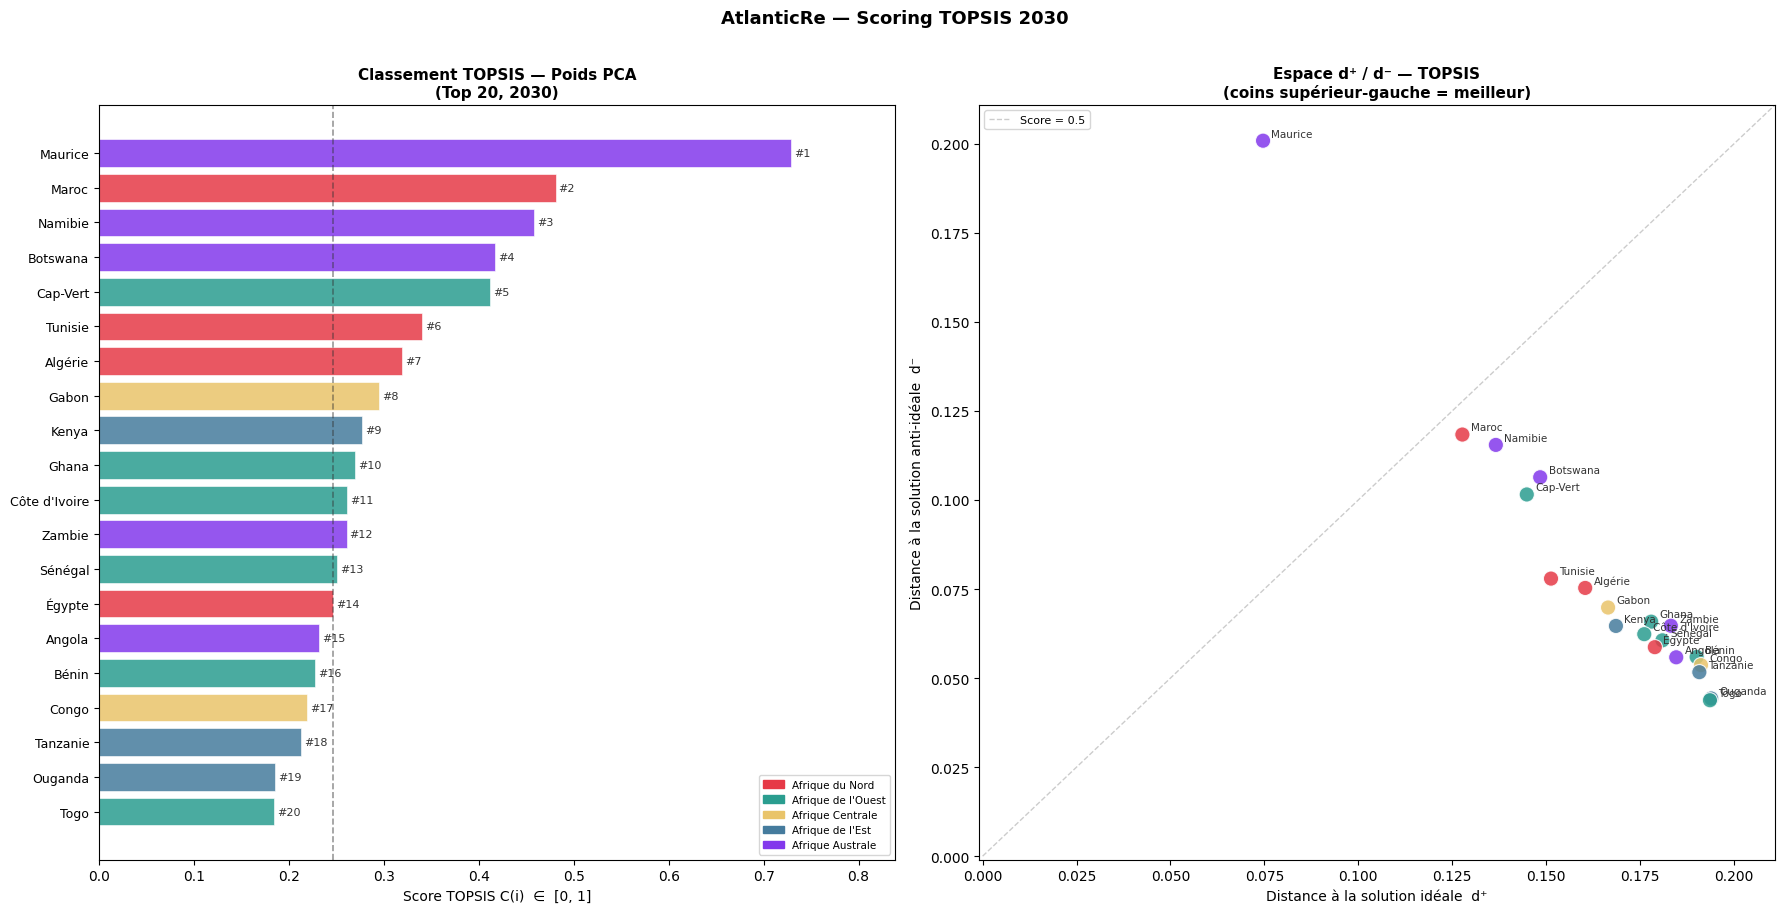

✅ topsis_scores.png sauvegardé


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(18, 9))

# ── Axe gauche : barplot scores TOPSIS ────────────────────────────────────
ax = axes[0]
df_plot = df_topsis.head(20).copy()
colors  = [REGION_COLORS[r] for r in df_plot['Region']]

bars = ax.barh(
    range(len(df_plot)), df_plot['score_topsis'],
    color=colors, alpha=0.85, edgecolor='white', linewidth=0.5
)

# Ligne verticale de référence : score moyen
ax.axvline(df_topsis['score_topsis'].mean(), color='#333', lw=1.2,
           ls='--', alpha=0.5, label='Score moyen')

# Annotations rang
for i, (_, row) in enumerate(df_plot.iterrows()):
    ax.text(row['score_topsis'] + 0.003, i, f'#{row["rang_topsis"]}',
            va='center', fontsize=8, color='#333')

ax.set_yticks(range(len(df_plot)))
ax.set_yticklabels(df_plot['Pays'], fontsize=9)
ax.invert_yaxis()
ax.set_xlabel('Score TOPSIS C(i)  ∈  [0, 1]', fontsize=10)
ax.set_title('Classement TOPSIS — Poids PCA\n(Top 20, 2030)', fontsize=11, fontweight='bold')
ax.set_xlim(0, df_topsis['score_topsis'].max() * 1.15)

# Légende régions
patches = [mpatches.Patch(color=v, label=k) for k, v in REGION_COLORS.items()]
ax.legend(handles=patches, loc='lower right', fontsize=7.5, framealpha=0.8)

# ── Axe droit : diagramme d+ / d− ─────────────────────────────────────────
ax2 = axes[1]
x   = df_plot['d_plus'].values
y   = df_plot['d_minus'].values
col = [REGION_COLORS[r] for r in df_plot['Region']]

sc = ax2.scatter(x, y, c=col, s=120, alpha=0.85, edgecolors='white', linewidths=0.8, zorder=3)

for i, (_, row) in enumerate(df_plot.iterrows()):
    ax2.annotate(
        row['Pays'],
        (row['d_plus'], row['d_minus']),
        textcoords='offset points', xytext=(6, 3),
        fontsize=7.5, color='#333'
    )

# Ligne iso-score : d- = d+ → score = 0.5
lim = max(x.max(), y.max()) * 1.05
ax2.plot([0, lim], [0, lim], '--', color='gray', alpha=0.4, lw=1, label='Score = 0.5')

ax2.set_xlabel('Distance à la solution idéale  d⁺', fontsize=10)
ax2.set_ylabel('Distance à la solution anti-idéale  d⁻', fontsize=10)
ax2.set_title('Espace d⁺ / d⁻ — TOPSIS\n(coins supérieur-gauche = meilleur)', fontsize=11, fontweight='bold')
ax2.legend(fontsize=8)
ax2.set_xlim(-0.001, lim)
ax2.set_ylim(-0.001, lim)

plt.suptitle('AtlanticRe — Scoring TOPSIS 2030', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('topsis_scores.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ topsis_scores.png sauvegardé')

### 6.2 Heatmap de Sensibilité — Stabilité du Classement

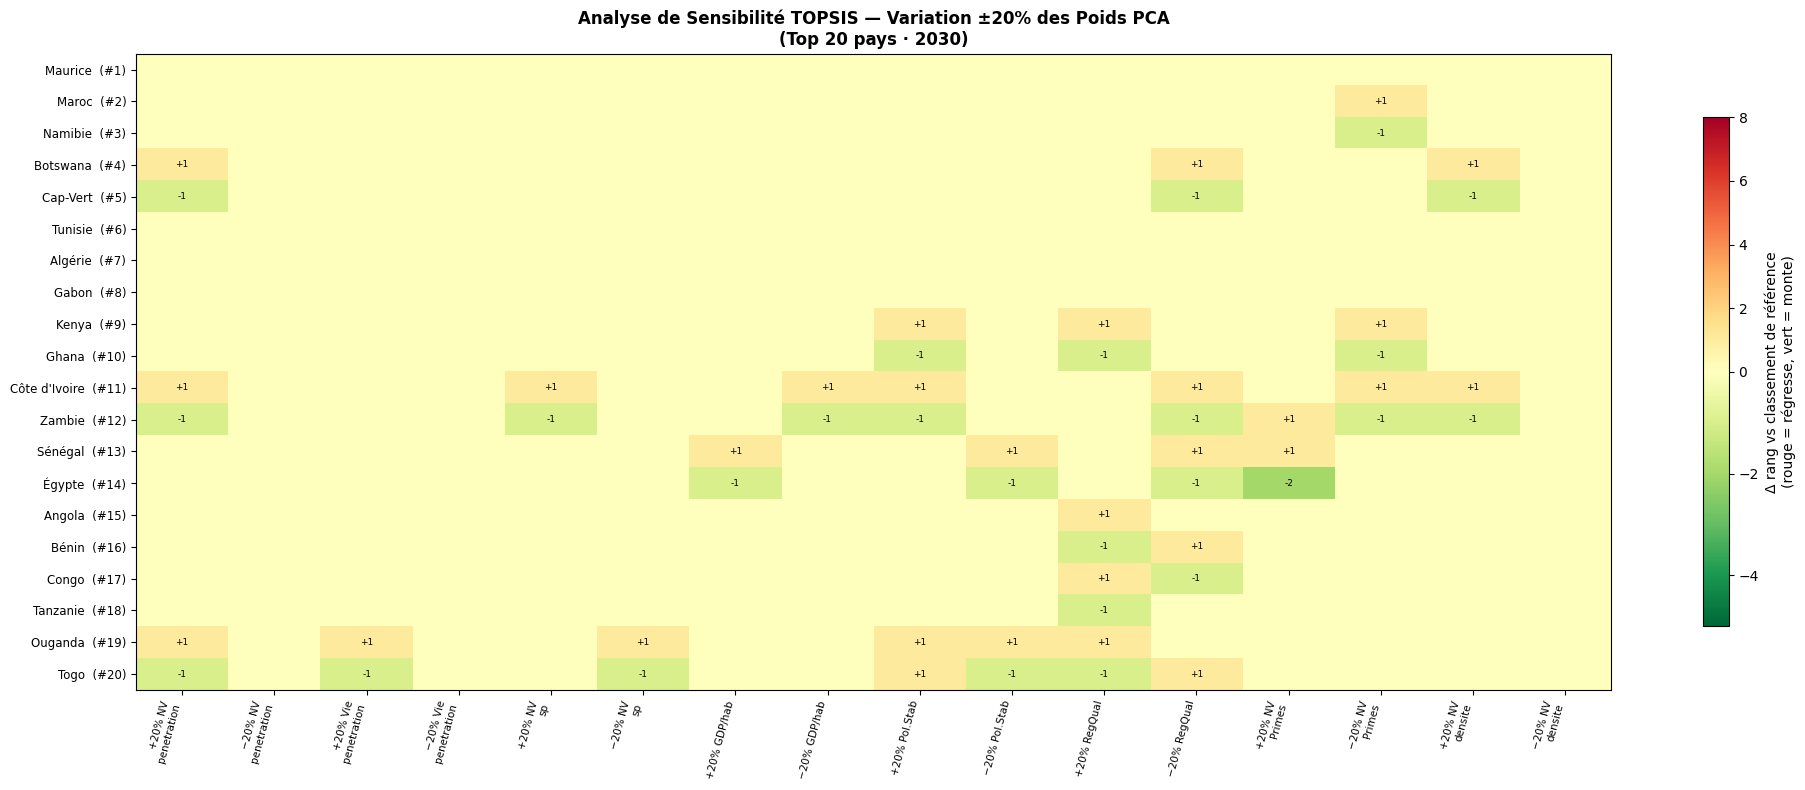

✅ topsis_sensitivity.png sauvegardé


In [12]:
# ── Matrice de stabilité : rang médian par scénario de perturbation ─────
# Pour chaque critère j perturbé ±20% : rang de chaque pays

TOP20_PAYS   = df_topsis.head(20)['Pays'].tolist()
crit_labels  = [c.replace('_pred', '').replace('nv_', 'NV\n').replace('vie_', 'Vie\n')
                 .replace('gdpcap', 'GDP/hab').replace('polstab', 'Pol.Stab')
                 .replace('regqual', 'RegQual').replace('primes', 'Primes') for c in CRITERIA_COLS]

# Construire matrice des rangs pour perturbations ±20%
n_scenarios = len(sens_results)  # 2 × N_CRIT = 16
mat = np.zeros((len(TOP20_PAYS), n_scenarios))

for s, sr in enumerate(sens_results):
    for pi, pays in enumerate(TOP20_PAYS):
        orig_idx = pays_list.index(pays)
        mat[pi, s] = sr['rangs'][orig_idx]

# Rang de référence (TOPSIS PCA)
rang_ref = np.array([df_topsis.loc[df_topsis['Pays'] == p, 'rang_topsis'].values[0]
                     for p in TOP20_PAYS])

# Matrice delta rang vs référence
mat_delta = mat - rang_ref[:, np.newaxis]  # >0 = régresse, <0 = monte

# Labels des colonnes
col_labels = []
for j in range(N_CRIT):
    col_labels.append(f'+20% {crit_labels[j]}')
    col_labels.append(f'−20% {crit_labels[j]}')

fig, ax = plt.subplots(figsize=(20, 8))

cmap = plt.cm.RdYlGn_r
norm = mcolors.TwoSlopeNorm(vmin=-5, vcenter=0, vmax=8)

im = ax.imshow(mat_delta, aspect='auto', cmap=cmap, norm=norm)

ax.set_xticks(range(n_scenarios))
ax.set_xticklabels(col_labels, rotation=75, ha='right', fontsize=7.5)
ax.set_yticks(range(len(TOP20_PAYS)))
ax.set_yticklabels(
    [f'{p}  (#{int(r)})' for p, r in zip(TOP20_PAYS, rang_ref)],
    fontsize=8.5
)

# Annoter les valeurs
for pi in range(len(TOP20_PAYS)):
    for s in range(n_scenarios):
        val = int(mat_delta[pi, s])
        if val != 0:
            ax.text(s, pi, f'{val:+d}', ha='center', va='center',
                    fontsize=6.5, color='white' if abs(val) > 3 else 'black')

plt.colorbar(im, ax=ax, label='Δ rang vs classement de référence\n(rouge = régresse, vert = monte)', shrink=0.8)
ax.set_title('Analyse de Sensibilité TOPSIS — Variation ±20% des Poids PCA\n'
             '(Top 20 pays · 2030)', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('topsis_sensitivity.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ topsis_sensitivity.png sauvegardé')

### 6.3 Comparaison des 3 Versions TOPSIS + Axe 2

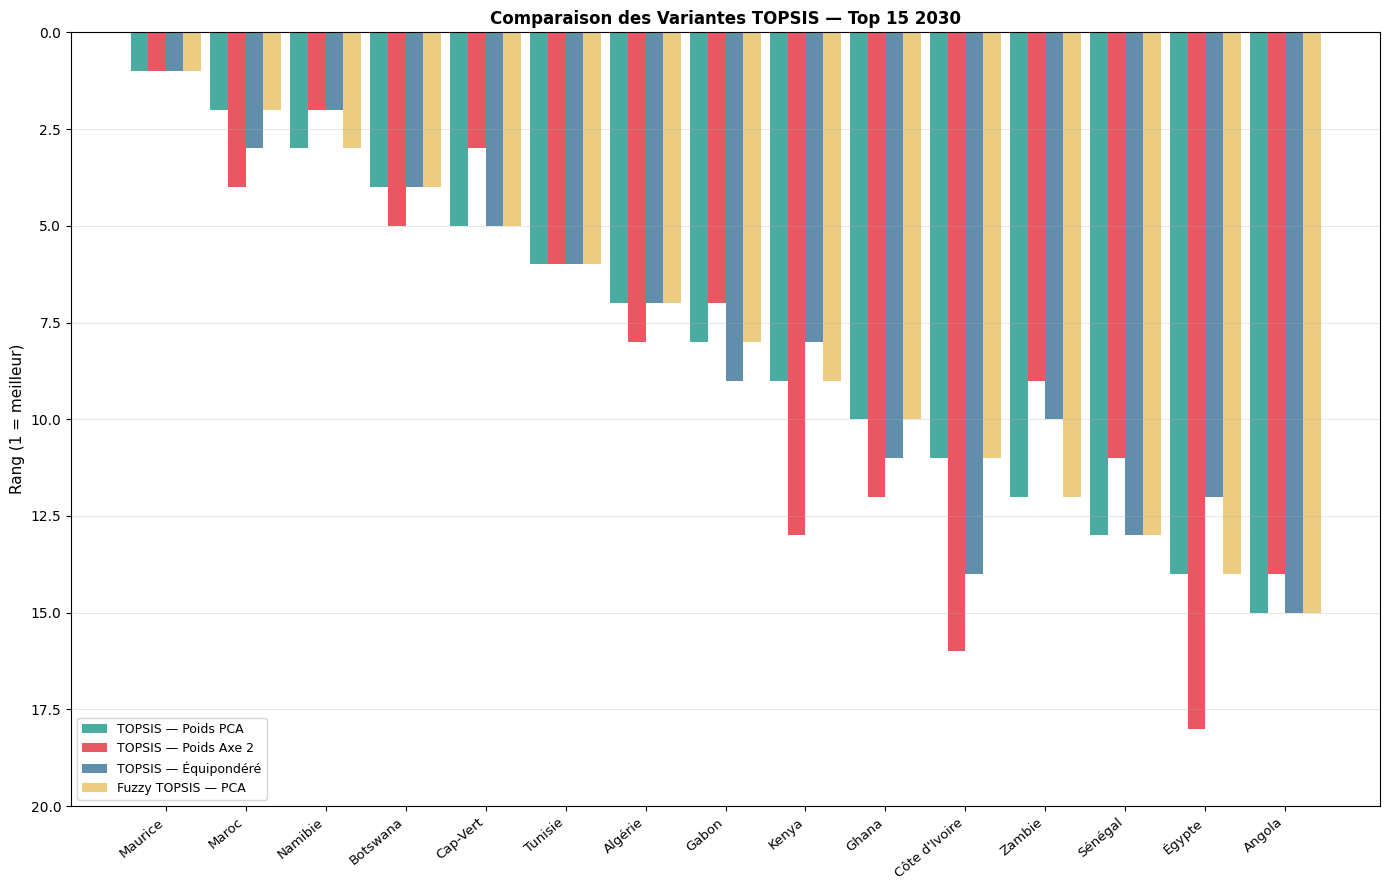

✅ topsis_variants_comparison.png sauvegardé


In [13]:
fig, ax = plt.subplots(figsize=(14, 9))

TOP15 = df_topsis.head(15)['Pays'].tolist()
x = np.arange(len(TOP15))
width = 0.22

# Récupérer les rangs pour chaque méthode
def get_rangs(col_rang, pays_list_ref):
    return [df_topsis.loc[df_topsis['Pays'] == p, col_rang].values[0] for p in pays_list_ref]

r_pca    = get_rangs('rang_topsis', TOP15)
r_axe2t  = get_rangs('rang_topsis_axe2w', TOP15)
r_equal  = get_rangs('rang_topsis_equal', TOP15)
r_fuzzy  = get_rangs('rang_fuzzy_topsis', TOP15)

ax.bar(x - 1.5*width, r_pca,   width, label='TOPSIS — Poids PCA',    color='#2a9d8f', alpha=0.85)
ax.bar(x - 0.5*width, r_axe2t, width, label='TOPSIS — Poids Axe 2',  color='#e63946', alpha=0.85)
ax.bar(x + 0.5*width, r_equal, width, label='TOPSIS — Équipondéré',   color='#457b9d', alpha=0.85)
ax.bar(x + 1.5*width, r_fuzzy, width, label='Fuzzy TOPSIS — PCA',    color='#e9c46a', alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels(TOP15, rotation=40, ha='right', fontsize=9.5)
ax.set_ylabel('Rang (1 = meilleur)', fontsize=11)
ax.set_title('Comparaison des Variantes TOPSIS — Top 15 2030', fontsize=12, fontweight='bold')
ax.invert_yaxis()
ax.set_ylim(20, 0)
ax.legend(fontsize=9, loc='lower left')
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('topsis_variants_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ topsis_variants_comparison.png sauvegardé')

### 6.4 Intervalle de Confiance du Rang (Monte Carlo des Poids)

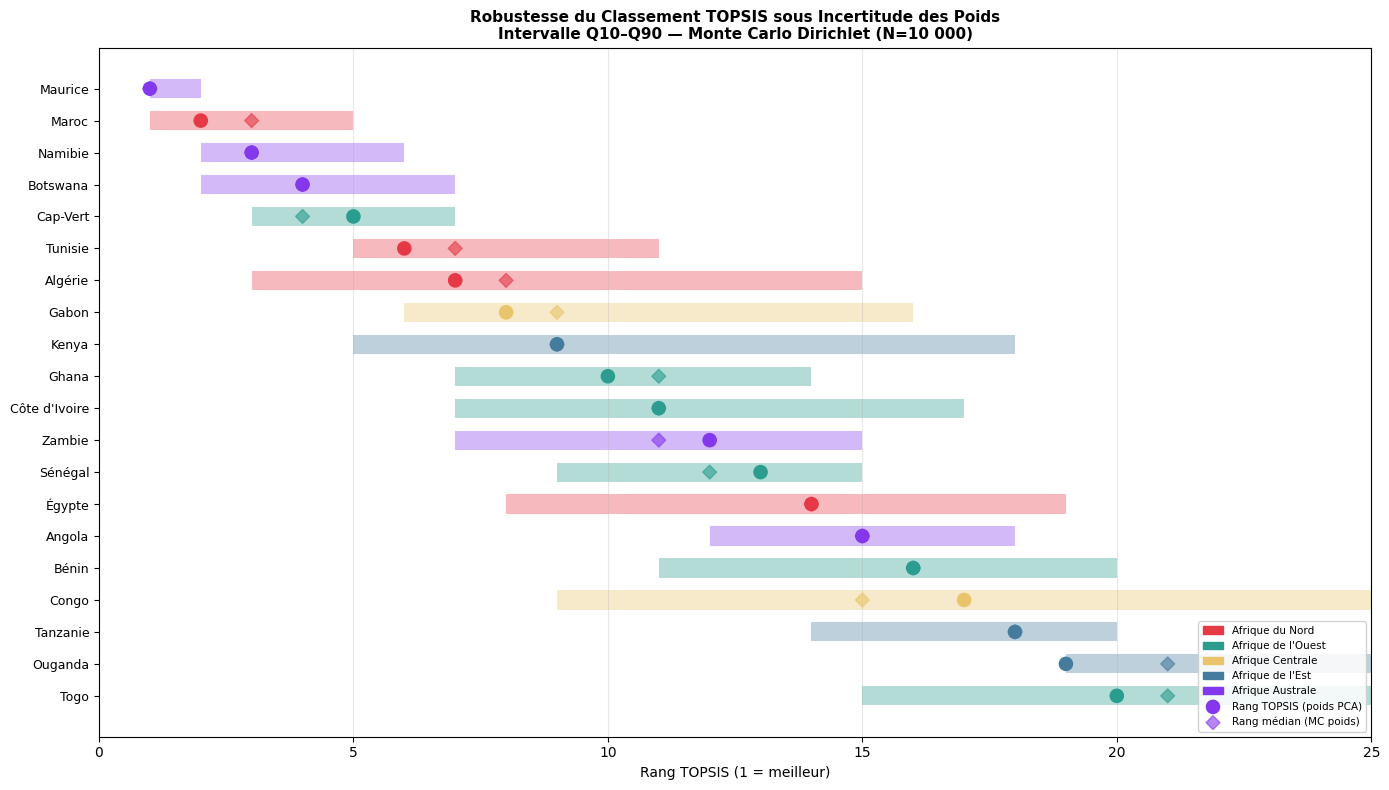

✅ topsis_robustness_mc.png sauvegardé


In [14]:
fig, ax = plt.subplots(figsize=(14, 8))

df_plot = df_topsis.head(20).copy()

# Calcul de la largeur de l'intervalle Q10–Q90
ci_low  = df_plot['rang_q10_sens'].values
ci_high = df_plot['rang_q90_sens'].values
ci_mid  = df_plot['rang_topsis'].values
pays_names = df_plot['Pays'].tolist()
colors_list = [REGION_COLORS[r] for r in df_plot['Region']]

y = np.arange(len(df_plot))

# Barres d'erreur [Q10, Q90]
ax.barh(y, ci_high - ci_low, left=ci_low, height=0.6,
        color=[REGION_COLORS[r] for r in df_plot['Region']],
        alpha=0.35, label='Intervalle Q10–Q90 (sensibilité poids)')

# Points : rang de référence
ax.scatter(ci_mid, y, color=colors_list, s=90, zorder=5, label='Rang TOPSIS (poids PCA)')

# Points : rang médian MC
ax.scatter(df_plot['rang_median_sens'].values, y,
           marker='D', color=colors_list, s=50, zorder=5, alpha=0.6,
           label='Rang médian (MC poids)')

ax.set_yticks(y)
ax.set_yticklabels(pays_names, fontsize=9)
ax.invert_yaxis()
ax.set_xlabel('Rang TOPSIS (1 = meilleur)', fontsize=10)
ax.set_title('Robustesse du Classement TOPSIS sous Incertitude des Poids\n'
             'Intervalle Q10–Q90 — Monte Carlo Dirichlet (N=10 000)', fontsize=11, fontweight='bold')
ax.set_xlim(0, 25)
ax.legend(fontsize=9, loc='lower right')
ax.grid(axis='x', alpha=0.3)

patches = [mpatches.Patch(color=v, label=k) for k, v in REGION_COLORS.items()]
ax.legend(handles=patches + ax.get_legend_handles_labels()[0][:2],
          loc='lower right', fontsize=7.5, framealpha=0.85)

plt.tight_layout()
plt.savefig('topsis_robustness_mc.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ topsis_robustness_mc.png sauvegardé')

### 6.5 Heatmap Contribution par Critère (Performance relative dans l'espace TOPSIS)

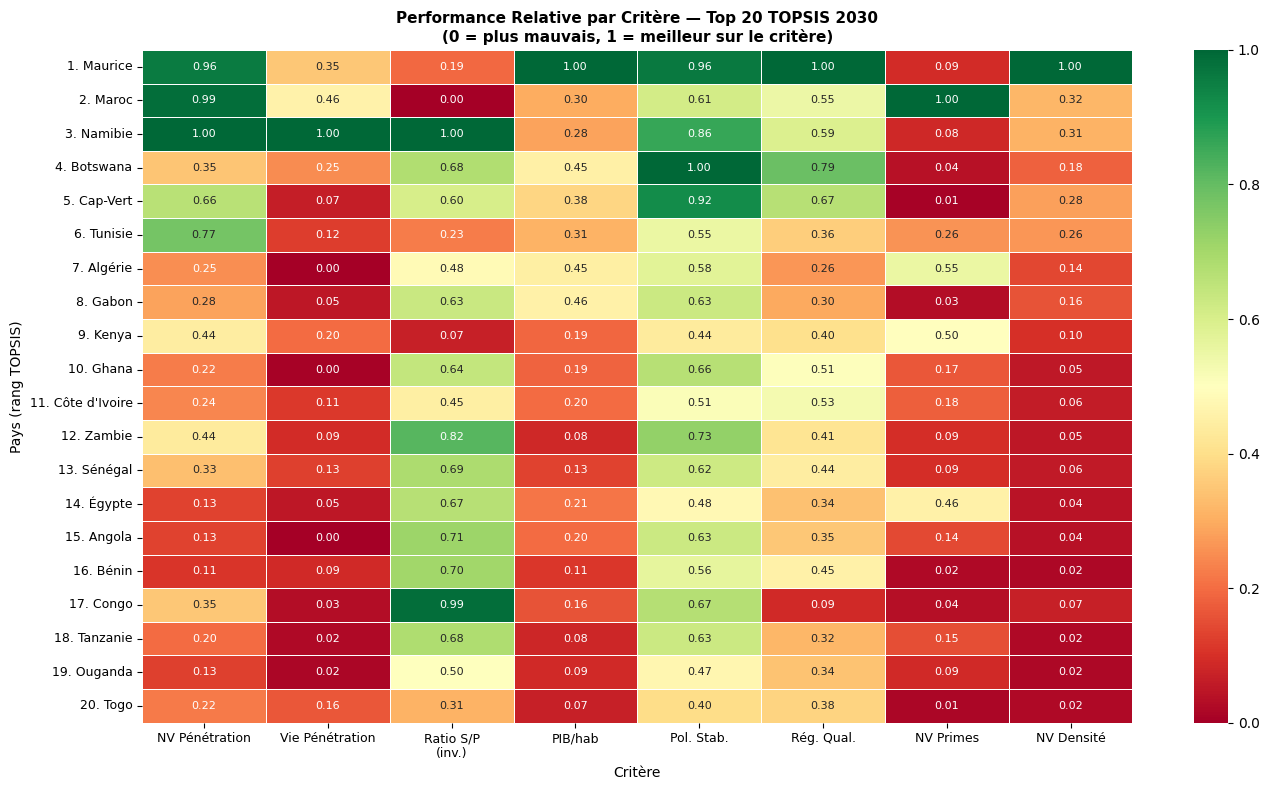

✅ topsis_criteria_heatmap.png sauvegardé


In [15]:
# ── Contribution de chaque critère au score TOPSIS ─────────────────────
# V_pca est la matrice pondérée normalisée : (n_pays, n_crit)
# Pour chaque pays, calculer sa position relative à A+ et A- sur chaque dimension

# Normalisation min-max pour la heatmap
V_norm = (V_pca - V_pca.min(axis=0)) / (V_pca.max(axis=0) - V_pca.min(axis=0) + 1e-12)

# Inverser les critères coût pour que "haut" = bon partout
for j, col in enumerate(CRITERIA_COLS):
    if col in COST:
        V_norm[:, j] = 1 - V_norm[:, j]

# Top 20 pays triés par rang TOPSIS
TOP20_IDX = [pays_list.index(p) for p in df_topsis.head(20)['Pays']]

crit_display = ['NV Pénétration', 'Vie Pénétration', 'Ratio S/P\n(inv.)',
                'PIB/hab', 'Pol. Stab.', 'Rég. Qual.', 'NV Primes', 'NV Densité']

fig, ax = plt.subplots(figsize=(14, 8))

df_heat = pd.DataFrame(
    V_norm[TOP20_IDX, :],
    index=[f"{i+1}. {pays_list[idx]}" for i, idx in enumerate(TOP20_IDX)],
    columns=crit_display
)

sns.heatmap(
    df_heat,
    cmap='RdYlGn',
    annot=True, fmt='.2f', annot_kws={'size': 8},
    linewidths=0.5,
    vmin=0, vmax=1,
    ax=ax
)

ax.set_title('Performance Relative par Critère — Top 20 TOPSIS 2030\n'
             '(0 = plus mauvais, 1 = meilleur sur le critère)', fontsize=11, fontweight='bold')
ax.set_xlabel('Critère', fontsize=10)
ax.set_ylabel('Pays (rang TOPSIS)', fontsize=10)
ax.tick_params(axis='y', labelsize=9)
ax.tick_params(axis='x', labelsize=9)

plt.tight_layout()
plt.savefig('topsis_criteria_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ topsis_criteria_heatmap.png sauvegardé')

### 6.6 Comparaison Multi-Méthodes — TOPSIS vs Monte Carlo vs Axe 2

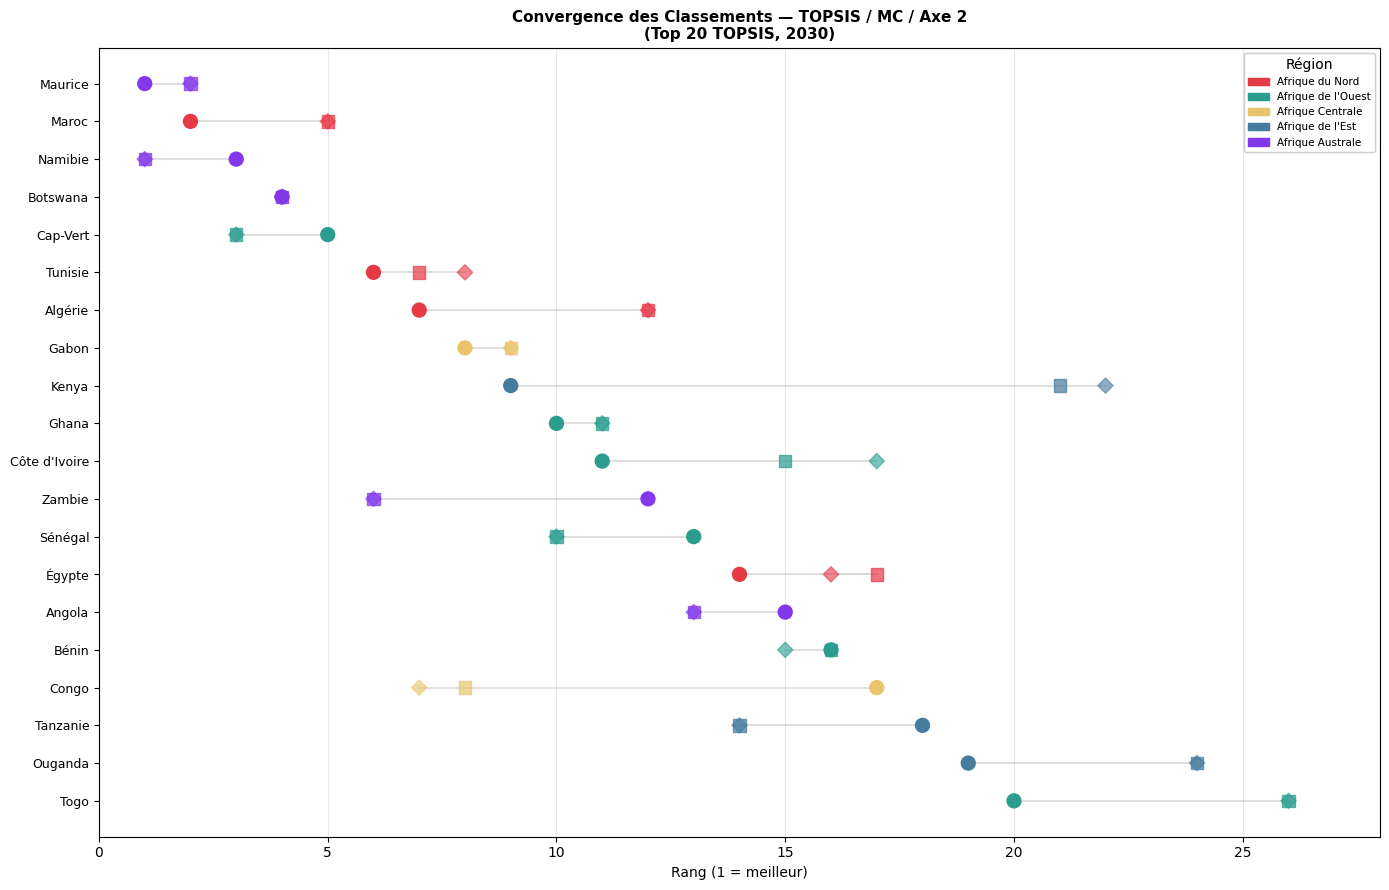

✅ topsis_vs_mc_vs_axe2.png sauvegardé


In [16]:
if HAS_MC:
    fig, ax = plt.subplots(figsize=(14, 9))

    # Fusionner les classements
    df_comp_all = df_topsis[['Pays', 'Region', 'rang_topsis']].copy()
    df_mc_merge = df_mc[['Pays', 'rang_P50']].rename(columns={'rang_P50': 'rang_mc_p50'})
    df_comp_all = df_comp_all.merge(df_mc_merge, on='Pays', how='left')

    if HAS_AXE2:
        # df_axe2 a été lu avec index_col=0 → l'index contient déjà les rangs
        # 1..33 tels qu'exportés par Axe 2 (index=True). Pas de +1 nécessaire.
        df_axe2_merge = df_axe2[['Pays']].copy()
        df_axe2_merge['rang_axe2'] = df_axe2.index  # rangs 1..33 depuis l'index CSV
        assert df_axe2_merge['rang_axe2'].between(1, 33).all(), \
            "rang_axe2 hors plage 1..33 — vérifier l'export Axe 2 (index=True)"
        df_comp_all = df_comp_all.merge(df_axe2_merge, on='Pays', how='left')

    df_comp_all = df_comp_all.sort_values('rang_topsis').head(20)

    y = np.arange(len(df_comp_all))
    pays_names_comp = df_comp_all['Pays'].tolist()
    cols_comp = [REGION_COLORS[r] for r in df_comp_all['Region']]

    ax.scatter(df_comp_all['rang_topsis'].values,    y, c=cols_comp, marker='o', s=100,
               label='TOPSIS (poids PCA)', zorder=5)
    ax.scatter(df_comp_all['rang_mc_p50'].values,    y, c=cols_comp, marker='s', s=80,
               alpha=0.7, label='Monte Carlo P50', zorder=4)
    if HAS_AXE2 and 'rang_axe2' in df_comp_all.columns:
        ax.scatter(df_comp_all['rang_axe2'].values,  y, c=cols_comp, marker='D', s=60,
                   alpha=0.6, label='Score Axe 2 (déterministe)', zorder=3)

    # Lignes reliant les méthodes pour chaque pays
    for i, (_, row) in enumerate(df_comp_all.iterrows()):
        rangs_row = [row['rang_topsis'], row['rang_mc_p50']]
        if HAS_AXE2 and 'rang_axe2' in row:
            rangs_row.append(row['rang_axe2'])
        ax.plot(rangs_row, [i]*len(rangs_row), '-', color='gray', alpha=0.3, lw=1.2)

    ax.set_yticks(y)
    ax.set_yticklabels(pays_names_comp, fontsize=9)
    ax.invert_yaxis()
    ax.set_xlabel('Rang (1 = meilleur)', fontsize=10)
    ax.set_title('Convergence des Classements — TOPSIS / MC / Axe 2\n(Top 20 TOPSIS, 2030)', 
                 fontsize=11, fontweight='bold')
    ax.legend(fontsize=9, loc='lower right')
    ax.grid(axis='x', alpha=0.3)
    ax.set_xlim(0, 28)

    patches = [mpatches.Patch(color=v, label=k) for k, v in REGION_COLORS.items()]
    legend1 = ax.legend(handles=patches, loc='upper right', fontsize=7.5, framealpha=0.85, title='Région')
    ax.add_artist(legend1)

    plt.tight_layout()
    plt.savefig('topsis_vs_mc_vs_axe2.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('✅ topsis_vs_mc_vs_axe2.png sauvegardé')
else:
    print('⚠️  Graphique 6.6 ignoré — fichier MC non disponible')

---
## 7. Synthèse & Interprétation

In [17]:
print('=' * 70)
print('  AtlanticRe — BLOC 4 : TOPSIS — TABLEAU DE BORD FINAL (2030)')
print('=' * 70)

print('\n📊 CLASSEMENT TOPSIS (poids PCA) — TOP 15 :')
print(df_topsis[['Pays', 'Region', 'rang_topsis', 'score_topsis',
                  'd_plus', 'd_minus', 'rang_fuzzy_topsis',
                  'prob_top5_sens']].head(15).to_string(index=False))

print('\n📊 PAYS LES PLUS ROBUSTES (amplitude rang ≤ 3 sous variation des poids) :')
df_robust = df_topsis[df_topsis['rang_amplitude_sens'] <= 3][['Pays', 'rang_topsis', 
    'rang_amplitude_sens', 'prob_top5_sens']].sort_values('rang_topsis')
print(df_robust.to_string(index=False))

print('\n📊 PAYS LES MOINS ROBUSTES (amplitude rang > 8 sous variation des poids) :')
df_fragile = df_topsis[df_topsis['rang_amplitude_sens'] > 8][['Pays', 'rang_topsis',
    'rang_amplitude_sens', 'prob_top5_sens']].sort_values('rang_topsis')
print(df_fragile.to_string(index=False))

print('\n📊 CONCORDANCE MÉTHODES (TOPSIS PCA vs Fuzzy TOPSIS) :')
corr_fuzzy = df_topsis['rang_topsis'].corr(df_topsis['rang_fuzzy_topsis'],
                                            method='spearman')
print(f'  Corrélation Spearman rang_TOPSIS vs rang_Fuzzy : ρ = {corr_fuzzy:.3f}')

if HAS_MC and 'rang_mc_p50' in df_comp_all.columns:
    df_m = df_topsis.merge(df_mc[['Pays', 'rang_P50']], on='Pays')
    corr_mc = df_m['rang_topsis'].corr(df_m['rang_P50'], method='spearman')
    print(f'  Corrélation Spearman rang_TOPSIS vs rang_MC_P50 : ρ = {corr_mc:.3f}')

print('\n📂 FICHIERS EXPORTÉS :')
print('  → scoring_topsis_2030_AtlanticRe.csv')
print('  → topsis_scores.png')
print('  → topsis_sensitivity.png')
print('  → topsis_variants_comparison.png')
print('  → topsis_robustness_mc.png')
print('  → topsis_criteria_heatmap.png')
print('  → topsis_vs_mc_vs_axe2.png')

print('\n▶ Prochaine étape : axe3_atlanticre_scoring_consolidation.ipynb')
print('   Inputs  : scoring_mc, scoring_pca, scoring_cluster, scoring_topsis, score_axe2')
print('   Outputs : classement consensus final + rapport AtlanticRe')
print('=' * 70)

  AtlanticRe — BLOC 4 : TOPSIS — TABLEAU DE BORD FINAL (2030)

📊 CLASSEMENT TOPSIS (poids PCA) — TOP 15 :
         Pays             Region  rang_topsis  score_topsis  d_plus  d_minus  rang_fuzzy_topsis  prob_top5_sens
      Maurice   Afrique Australe            1        0.7291 0.07464  0.20085                  1            99.4
        Maroc    Afrique du Nord            2        0.4810 0.12769  0.11836                  2            92.0
      Namibie   Afrique Australe            3        0.4580 0.13660  0.11545                  3            88.1
     Botswana   Afrique Australe            4        0.4175 0.14840  0.10637                  4            72.2
     Cap-Vert Afrique de l'Ouest            5        0.4121 0.14483  0.10154                  5            82.2
      Tunisie    Afrique du Nord            6        0.3400 0.15128  0.07792                  6            18.9
      Algérie    Afrique du Nord            7        0.3195 0.16038  0.07530                  7            21.

## Synthèse TOPSIS

Ce bloc implémente trois variantes de scoring multi-critères (TOPSIS classique, Fuzzy TOPSIS, analyse de sensibilité Monte Carlo des poids) sur 33 marchés africains en 2030. Les poids sont issus de la PCA (Bloc 1). Les intervalles de confiance à 90% des rangs, calculés sur 10 000 tirages Dirichlet, servent de bornes de robustesse pour le classement final.